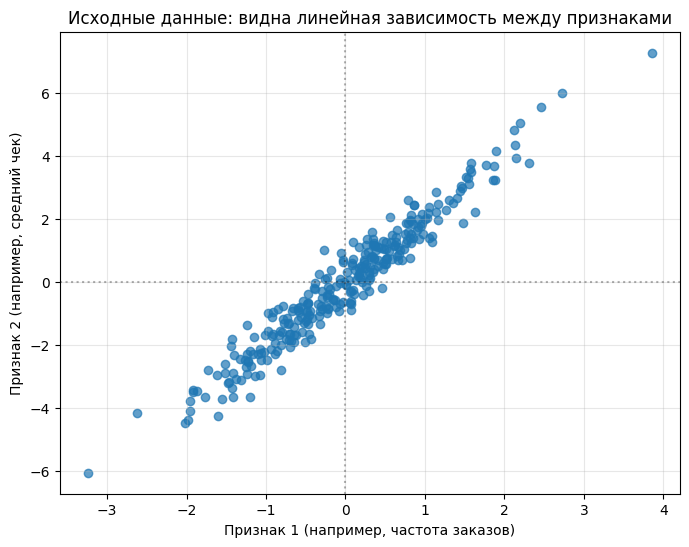

In [1]:
# @title
import numpy as np
import matplotlib.pyplot as plt

# Создадим "вытянутые" данные (как будто это 2 признака клиентов)
np.random.seed(42)
n_points = 300
# Основной тренд: второй признак примерно в 2 раза больше первого + шум
X = np.random.randn(n_points, 1)
data = np.hstack([X, 2 * X + np.random.randn(n_points, 1) * 0.5])

# Визуализируем
plt.figure(figsize=(8, 6))
plt.scatter(data[:, 0], data[:, 1], alpha=0.7)
plt.xlabel('Признак 1 (например, частота заказов)')
plt.ylabel('Признак 2 (например, средний чек)')
plt.title('Исходные данные: видна линейная зависимость между признаками')
plt.axhline(y=0, color='k', linestyle=':', alpha=0.3)
plt.axvline(x=0, color='k', linestyle=':', alpha=0.3)
plt.grid(True, alpha=0.3)
plt.show()

=== РЕЗУЛЬТАТЫ PCA ===
Главные компоненты (направляющие векторы):
PC1: [0.43380184 0.9010083 ] (направление максимальной дисперсии)
PC2: [ 0.9010083  -0.43380184] (перпендикулярно PC1)

Объяснённая дисперсия:
PC1 объясняет 99.1% дисперсии данных
PC2 объясняет 0.9% дисперсии данных


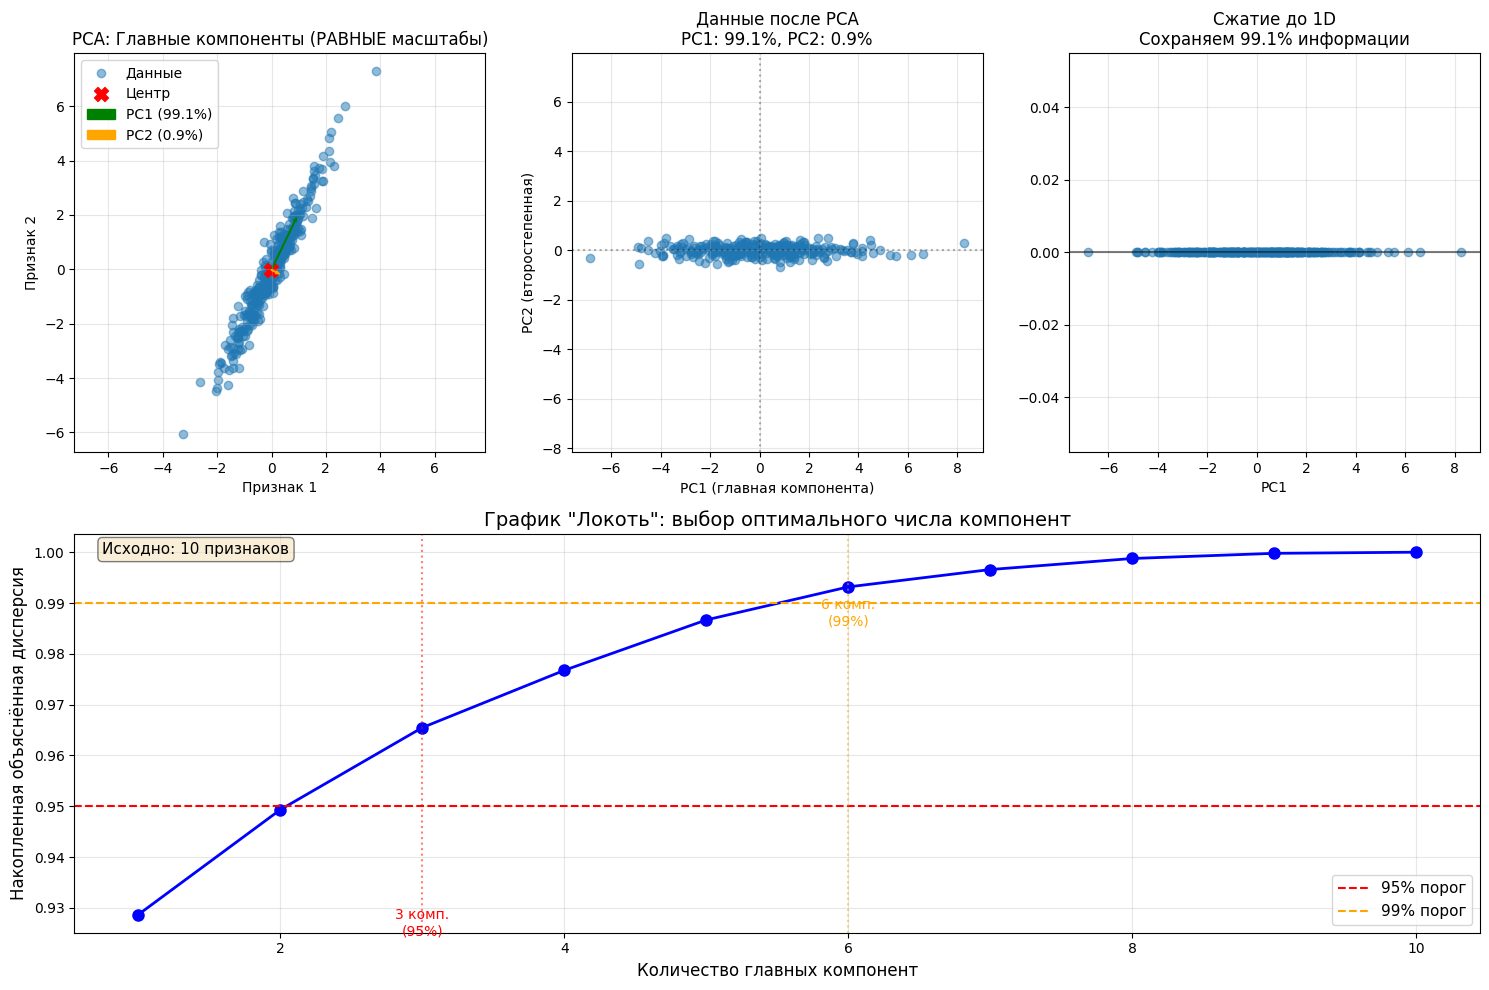


БИЗНЕС-АНАЛИЗ И РЕКОМЕНДАЦИИ ПО PCA

1. ДЛЯ ТЕСТОВЫХ ДАННЫХ (2 признака):
   • PC1 объясняет 99.1% дисперсии
   • Угол PC1: 63.2°
   • Рекомендация: Можно сжимать до 1D с потерей всего 0.9% информации

2. ДЛЯ РЕАЛЬНЫХ ДАННЫХ (10 признаков):
   • Для 95% информации нужно 3 компонент (вместо 10)
   • Для 99% информации нужно 6 компонент
   • Экономия памяти: 70% при 95% сохранения
   • Ускорение моделей: в ~3.3 раза

3. КОГДА ИСПОЛЬЗОВАТЬ PCA В ПРОДАКШЕНЕ:
   • Датчики/IoT: 100+ признаков → 10-20 компонент
   • Финансы: 50+ показателей → 5-10 компонент
   • Рекомендации: PCA + визуализация для поиска кластеров


In [5]:
# @title
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt
import numpy as np

# 1. Выполняем PCA (с 2 компонентами, чтобы увидеть обе)
pca = PCA(n_components=2)
pca.fit(data)

# 2. Получаем результаты
components = pca.components_  # Направляющие векторы новых осей
explained_variance = pca.explained_variance_ratio_  # Сколько дисперсии "объясняет" каждая компонента

print("=== РЕЗУЛЬТАТЫ PCA ===")
print(f"Главные компоненты (направляющие векторы):")
print(f"PC1: {components[0]} (направление максимальной дисперсии)")
print(f"PC2: {components[1]} (перпендикулярно PC1)")
print(f"\nОбъяснённая дисперсия:")
print(f"PC1 объясняет {explained_variance[0]:.1%} дисперсии данных")
print(f"PC2 объясняет {explained_variance[1]:.1%} дисперсии данных")

# 3. ВИЗУАЛИЗАЦИЯ PCA с ПРАВИЛЬНЫМИ МАСШТАБАМИ
fig = plt.figure(figsize=(15, 10))

# График 1: Исходные данные с главными компонентами (РАВНЫЕ МАСШТАБЫ)
ax1 = plt.subplot(2, 3, 1)
ax1.scatter(data[:, 0], data[:, 1], alpha=0.5, label='Данные')
mean_x, mean_y = data.mean(axis=0)
ax1.scatter(mean_x, mean_y, c='red', s=100, marker='X', label='Центр')

# Рисуем ПРАВИЛЬНО масштабированные компоненты
scale = 2  # Масштаб для наглядности
pc1 = components[0] * np.sqrt(explained_variance[0]) * scale
pc2 = components[1] * np.sqrt(explained_variance[1]) * scale

ax1.arrow(mean_x, mean_y, pc1[0], pc1[1],
          width=0.02, head_width=0.1, color='green',
          label=f'PC1 ({explained_variance[0]:.1%})')
ax1.arrow(mean_x, mean_y, pc2[0], pc2[1],
          width=0.02, head_width=0.1, color='orange',
          label=f'PC2 ({explained_variance[1]:.1%})')

ax1.set_xlabel('Признак 1')
ax1.set_ylabel('Признак 2')
ax1.set_title('PCA: Главные компоненты (РАВНЫЕ масштабы)')
ax1.legend()
ax1.grid(True, alpha=0.3)
ax1.axis('equal')  # КРИТИЧЕСКИ ВАЖНО!

# График 2: Данные в пространстве PCA
ax2 = plt.subplot(2, 3, 2)
data_transformed = pca.transform(data)
ax2.scatter(data_transformed[:, 0], data_transformed[:, 1], alpha=0.5)
ax2.set_xlabel('PC1 (главная компонента)')
ax2.set_ylabel('PC2 (второстепенная)')
ax2.set_title(f'Данные после PCA\nPC1: {explained_variance[0]:.1%}, PC2: {explained_variance[1]:.1%}')
ax2.axhline(y=0, color='k', linestyle=':', alpha=0.3)
ax2.axvline(x=0, color='k', linestyle=':', alpha=0.3)
ax2.grid(True, alpha=0.3)
ax2.axis('equal')

# График 3: Сжатие до 1D (только PC1)
ax3 = plt.subplot(2, 3, 3)
ax3.scatter(data_transformed[:, 0], np.zeros_like(data_transformed[:, 0]), alpha=0.5)
ax3.set_xlabel('PC1')
ax3.set_ylabel(' ')
ax3.set_title(f'Сжатие до 1D\nСохраняем {explained_variance[0]:.1%} информации')
ax3.axhline(y=0, color='k', linestyle='-', alpha=0.5)
ax3.grid(True, alpha=0.3)

# График 4: ЛОКОТЬ для реальных данных (10 признаков)
ax4 = plt.subplot(2, 3, (4, 6))  # Объединяем две ячейки

# Создаём реалистичные данные с 10 признаками
np.random.seed(42)
n_samples, n_features = 500, 10
base = np.random.randn(n_samples)
real_data = np.column_stack([base * (i+1) + np.random.randn(n_samples) * 0.3 * (i+1)
                            for i in range(n_features)])

pca_real = PCA()
pca_real.fit(real_data)
explained_var_real = np.cumsum(pca_real.explained_variance_ratio_)

# График "локоть"
ax4.plot(range(1, n_features+1), explained_var_real, 'bo-', linewidth=2, markersize=8)
ax4.axhline(y=0.95, color='red', linestyle='--', linewidth=1.5, label='95% порог')
ax4.axhline(y=0.99, color='orange', linestyle='--', linewidth=1.5, label='99% порог')

# Находим точки пересечения
n_components_95 = np.argmax(explained_var_real >= 0.95) + 1
n_components_99 = np.argmax(explained_var_real >= 0.99) + 1

ax4.axvline(x=n_components_95, color='red', linestyle=':', alpha=0.5)
ax4.axvline(x=n_components_99, color='orange', linestyle=':', alpha=0.5)

ax4.set_xlabel('Количество главных компонент', fontsize=12)
ax4.set_ylabel('Накопленная объяснённая дисперсия', fontsize=12)
ax4.set_title('График "Локоть": выбор оптимального числа компонент', fontsize=14)
ax4.grid(True, alpha=0.3)
ax4.legend(fontsize=11)

# Аннотации
ax4.text(n_components_95, 0.93, f'{n_components_95} комп.\n(95%)',
         ha='center', va='top', fontsize=10, color='red')
ax4.text(n_components_99, 0.985, f'{n_components_99} комп.\n(99%)',
         ha='center', va='bottom', fontsize=10, color='orange')

ax4.text(0.02, 0.98, f'Исходно: {n_features} признаков',
         transform=ax4.transAxes, fontsize=11, verticalalignment='top',
         bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.5))

plt.tight_layout()
plt.show()

# 4. БИЗНЕС-ВЫВОДЫ
print("\n" + "="*60)
print("БИЗНЕС-АНАЛИЗ И РЕКОМЕНДАЦИИ ПО PCA")
print("="*60)

print(f"\n1. ДЛЯ ТЕСТОВЫХ ДАННЫХ (2 признака):")
print(f"   • PC1 объясняет {explained_variance[0]:.1%} дисперсии")
print(f"   • Угол PC1: {angle_deg:.1f}°")
print(f"   • Рекомендация: Можно сжимать до 1D с потерей всего {100 - explained_variance[0]*100:.1f}% информации")

print(f"\n2. ДЛЯ РЕАЛЬНЫХ ДАННЫХ (10 признаков):")
print(f"   • Для 95% информации нужно {n_components_95} компонент (вместо {n_features})")
print(f"   • Для 99% информации нужно {n_components_99} компонент")
print(f"   • Экономия памяти: {((n_features - n_components_95) / n_features * 100):.0f}% при 95% сохранения")
print(f"   • Ускорение моделей: в ~{n_features / n_components_95:.1f} раза")

print(f"\n3. КОГДА ИСПОЛЬЗОВАТЬ PCA В ПРОДАКШЕНЕ:")
print(f"   • Датчики/IoT: 100+ признаков → 10-20 компонент")
print(f"   • Финансы: 50+ показателей → 5-10 компонент")
print(f"   • Рекомендации: PCA + визуализация для поиска кластеров")
print("="*60)

In [ ]:
# @title
# АНАЛИЗ "ЛОКОТЬ" ДЛЯ РЕАЛЬНЫХ ДАННЫХ (имитация)
# Создадим данные с 10 признаками (ближе к реальности)
np.random.seed(42)
n_samples, n_features = 1000, 10

# Создаём коррелированные признаки
base_feature = np.random.randn(n_samples)
real_data = np.zeros((n_samples, n_features))
for i in range(n_features):
    real_data[:, i] = base_feature * (i+1) + np.random.randn(n_samples) * 0.5 * (i+1)

# Анализируем, сколько компонент действительно нужно
pca_full = PCA()
pca_full.fit(real_data)

# График "локоть"
plt.figure(figsize=(10, 4))
plt.subplot(1, 2, 1)
explained_var = np.cumsum(pca_full.explained_variance_ratio_)
plt.plot(range(1, n_features+1), explained_var, 'bo-')
plt.xlabel('Количество главных компонент')
plt.ylabel('Накопленная объяснённая дисперсия')
plt.title('График "локоть" для PCA')
plt.grid(True, alpha=0.3)
plt.axhline(y=0.95, color='r', linestyle='--', alpha=0.5, label='95% порог')
plt.legend()

# Второй график: индивидуальный вклад
plt.subplot(1, 2, 2)
bars = plt.bar(range(1, n_features+1), pca_full.explained_variance_ratio_)
plt.xlabel('Номер главной компоненты')
plt.ylabel('Доля объяснённой дисперсии')
plt.title('Вклад каждой компоненты')
# Раскрасим первые 3 компоненты
for i in range(3):
    bars[i].set_color('green')
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# Анализ для бизнес-решения
print("\n=== БИЗНЕС-АНАЛИЗ ДЛЯ РЕШЕНИЯ ===")
print(f"Для сохранения 95% информации нужно {np.argmax(explained_var >= 0.95) + 1} компонент")
print(f"Сжатие: {n_features}D → {np.argmax(explained_var >= 0.95) + 1}D")
print(f"Экономия памяти и ускорение моделей: ~{((n_features - (np.argmax(explained_var >= 0.95) + 1)) / n_features * 100):.0f}%